<a href="https://colab.research.google.com/github/annaPP07/annaPP07/blob/main/anna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10 | train loss: 198.99, acc: 0.795 | val loss: 147.07, acc: 0.803
Epoch 2/10 | train loss: 140.73, acc: 0.805 | val loss: 134.44, acc: 0.804
Epoch 3/10 | train loss: 131.96, acc: 0.806 | val loss: 127.78, acc: 0.805
Epoch 4/10 | train loss: 126.90, acc: 0.807 | val loss: 124.04, acc: 0.805
Epoch 5/10 | train loss: 123.75, acc: 0.808 | val loss: 121.45, acc: 0.807
Epoch 6/10 | train loss: 121.57, acc: 0.808 | val loss: 119.52, acc: 0.807
Epoch 7/10 | train loss: 119.93, acc: 0.808 | val loss: 118.16, acc: 0.807
Epoch 8/10 | train loss: 118.61, acc: 0.808 | val loss: 116.99, acc: 0.808
Epoch 9/10 | train loss: 117.52, acc: 0.809 | val loss: 116.22, acc: 0.807
Epoch 10/10 | train loss: 116.68, acc: 0.809 | val loss: 115.24, acc: 0.808


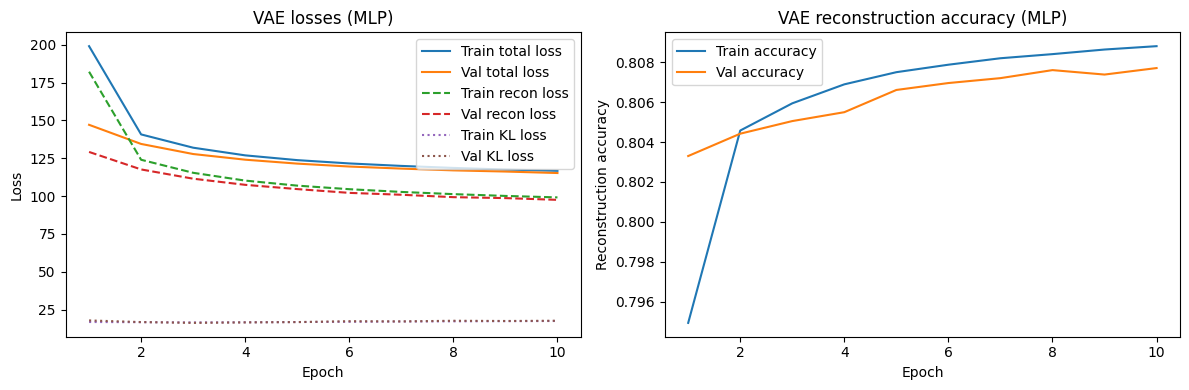

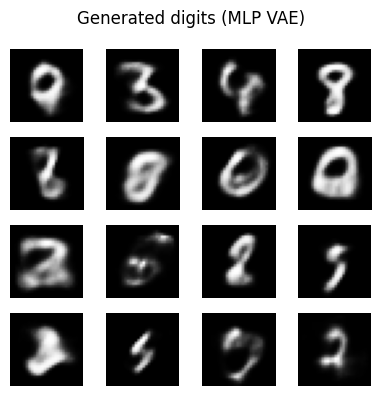

In [ ]:
# ===================== Импорты =====================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# ===================== Данные MNIST (упрощённая подготовка) =====================
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Нормализация к [0,1] и приведение к вектору (784)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

batch_size = 256  # крупный батч ускоряет обучение
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices(x_test).batch(batch_size)

# ===================== Параметры VAE =====================
latent_dim = 10  # небольшое латентное пространство — быстрее
hidden_dim = 256
epochs = 10      # меньше эпох => быстрее, можно увеличить при необходимости

# ===================== Encoder =====================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.dense1 = tf.keras.layers.Dense(hidden_dim, activation="relu")
        self.mean_layer = tf.keras.layers.Dense(latent_dim)
        self.logvar_layer = tf.keras.layers.Dense(latent_dim)

    def call(self, x):
        h = self.dense1(x)
        mean = self.mean_layer(h)
        log_var = self.logvar_layer(h)
        return mean, log_var

# ===================== Decoder =====================
class Decoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.dense1 = tf.keras.layers.Dense(hidden_dim, activation="relu")
        self.output_layer = tf.keras.layers.Dense(28 * 28, activation=None)  # logits

    def call(self, z):
        h = self.dense1(z)
        logits = self.output_layer(h)
        return logits

# ===================== VAE-модель =====================
class VAE(tf.keras.Model):
    def __init__(self, latent_dim, hidden_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim, hidden_dim)
        self.decoder = Decoder(latent_dim, hidden_dim)

    def encode(self, x):
        mean, log_var = self.encoder(x)
        return mean, log_var

    def reparameterize(self, mean, log_var):
        eps = tf.random.normal(shape=tf.shape(mean))
        std = tf.exp(0.5 * log_var)
        z = mean + std * eps
        return z

    def decode(self, z):
        logits = self.decoder(z)
        return logits

    def call(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        logits = self.decode(z)
        return mean, log_var, logits

    def reconstruction_loss(self, x, logits):
        # бинарная кросс‑энтропия по всем пикселям
        bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=x, logits=logits)
        bce = tf.reduce_sum(bce, axis=1)  # суммируем по 784
        return tf.reduce_mean(bce)

    def kl_divergence_loss(self, mean, log_var):
        # KL = -0.5 * sum(1 + log_var - mean^2 - exp(log_var))
        kl = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
        return tf.reduce_mean(kl)

    def vae_loss(self, x, logits, mean, log_var, beta=1.0):
        recon = self.reconstruction_loss(x, logits)
        kl = self.kl_divergence_loss(mean, log_var)
        total = recon + beta * kl
        return total, recon, kl

    @tf.function
    def train_step(self, x, optimizer):
        with tf.GradientTape() as tape:
            mean, log_var, logits = self(x, training=True)
            loss, recon_loss, kl_loss = self.vae_loss(x, logits, mean, log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return loss, recon_loss, kl_loss

    def generate(self, num_samples):
        z = tf.random.normal(shape=(num_samples, self.latent_dim))
        logits = self.decode(z)
        probs = tf.sigmoid(logits)
        return probs

# ===================== Инициализация и обучение =====================
vae = VAE(latent_dim, hidden_dim)
optimizer = tf.keras.optimizers.Adam(1e-3)

train_losses, train_recon_losses, train_kl_losses, train_accs = [], [], [], []
val_losses, val_recon_losses, val_kl_losses, val_accs = [], [], [], []

def reconstruction_accuracy(x, logits):
    probs = tf.sigmoid(logits)
    preds = tf.cast(probs > 0.5, tf.float32)
    correct = tf.cast(tf.equal(preds, x), tf.float32)
    return tf.reduce_mean(correct)

for epoch in range(1, epochs + 1):
    # ---- TRAIN ----
    epoch_loss, epoch_recon, epoch_kl, epoch_acc = [], [], [], []
    for batch in train_dataset:
        loss, recon, kl = vae.train_step(batch, optimizer)
        mean, log_var, logits = vae(batch, training=False)
        acc = reconstruction_accuracy(batch, logits)

        epoch_loss.append(loss.numpy())
        epoch_recon.append(recon.numpy())
        epoch_kl.append(kl.numpy())
        epoch_acc.append(acc.numpy())

    train_losses.append(np.mean(epoch_loss))
    train_recon_losses.append(np.mean(epoch_recon))
    train_kl_losses.append(np.mean(epoch_kl))
    train_accs.append(np.mean(epoch_acc))

    # ---- VALIDATION ----
    val_epoch_loss, val_epoch_recon, val_epoch_kl, val_epoch_acc = [], [], [], []
    for batch in test_dataset:
        mean, log_var, logits = vae(batch, training=False)
        loss, recon, kl = vae.vae_loss(batch, logits, mean, log_var)
        acc = reconstruction_accuracy(batch, logits)

        val_epoch_loss.append(loss.numpy())
        val_epoch_recon.append(recon.numpy())
        val_epoch_kl.append(kl.numpy())
        val_epoch_acc.append(acc.numpy())

    val_losses.append(np.mean(val_epoch_loss))
    val_recon_losses.append(np.mean(val_epoch_recon))
    val_kl_losses.append(np.mean(val_epoch_kl))
    val_accs.append(np.mean(val_epoch_acc))

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train loss: {train_losses[-1]:.2f}, acc: {train_accs[-1]:.3f} | "
        f"val loss: {val_losses[-1]:.2f}, acc: {val_accs[-1]:.3f}"
    )

# ===================== Графики ошибок и точности =====================
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train total loss")
plt.plot(epochs_range, val_losses, label="Val total loss")
plt.plot(epochs_range, train_recon_losses, "--", label="Train recon loss")
plt.plot(epochs_range, val_recon_losses, "--", label="Val recon loss")
plt.plot(epochs_range, train_kl_losses, ":", label="Train KL loss")
plt.plot(epochs_range, val_kl_losses, ":", label="Val KL loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE losses (MLP)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train accuracy")
plt.plot(epochs_range, val_accs, label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction accuracy")
plt.title("VAE reconstruction accuracy (MLP)")
plt.legend()

plt.tight_layout()
plt.show()

# ===================== Генерация новых изображений =====================
num_gen = 16
generated = vae.generate(num_gen).numpy().reshape(-1, 28, 28)

plt.figure(figsize=(4, 4))
for i in range(num_gen):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Generated digits (MLP VAE)")
plt.tight_layout()
plt.show()
